In [ ]:
!sudo apt-get -qq install -y fonts-nanum > /dev/null

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# 한글 폰트 적용
fm.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
print(f"사용 장치: {device}")

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
사용 장치: cuda


In [ ]:
from google.colab import drive
import zipfile
import os

# 1. 구글 드라이브 마운트 (연동)
drive.mount('/content/drive')

# 2. 코랩이 허용하는 안전한 경로에 폴더 생성
real_kaggle_dir = '/content/kaggle/input/ai12-level1-project'
os.makedirs(real_kaggle_dir, exist_ok=True)

# 3. 루트(/) 경로에 가짜 지름길(심볼릭 링크) 생성
# 시스템 권한 문제를 우회하기 위해 느낌표(!)를 붙여 리눅스 관리자 명령어로 강제 연결합니다.
!ln -s /content/kaggle /kaggle 2>/dev/null || true

# 4. 내 구글 드라이브에 올린 zip 파일을 안전한 경로에 압축 해제
# (주의: 구글 드라이브 홈 화면 바로 아래에 zip 파일이 있다고 가정합니다)
drive_zip_path = '/content/drive/MyDrive/ai12-level1-project.zip'

print("📦 캐글 매핑 경로에 데이터셋 압축 해제 시작...")
with zipfile.ZipFile(drive_zip_path, 'r') as zip_ref:
    zip_ref.extractall(real_kaggle_dir)
    print("🎯 완료! 이제 코랩이 캐글인 것처럼 데이터를 읽을 수 있습니다.")

Mounted at /content/drive
📦 캐글 매핑 경로에 데이터셋 압축 해제 시작...
🎯 완료! 이제 코랩이 캐글인 것처럼 데이터를 읽을 수 있습니다.


In [ ]:
import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# 1. 데이터 경로 설정 (앞서 심볼릭 링크로 뚫어놓은 캐글 가상 경로 활용)
image_dir = '/content/kaggle/input/ai12-level1-project/sprint_ai_project1_data/train_images'

image_data = []
supported_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.JPG', '.JPEG', '.PNG')

# 2. 200개 이미지 전수조사 (크기 및 비율 추출)
print("🔍 이미지 데이터셋 분석 중...")
for file_name in tqdm(os.listdir(image_dir)):
    if file_name.endswith(supported_extensions):
        file_path = os.path.join(image_dir, file_name)

        # 이미지 읽기 (OpenCV 활용)
        img = cv2.imread(file_path)
        if img is not None:
            height, width, channels = img.shape
            aspect_ratio = width / height

            image_data.append({
                'file_name': file_name,
                'width': width,
                'height': height,
                'ratio': aspect_ratio,
                'pixels': width * height
            })

# 데이터프레임 변환
df = pd.DataFrame(image_data)

# 3. 통계치 요약 출력 (발표 장표 텍스트용)
print("\n=== 📈 이미지 크기 통계 요약 ===")
print(df[['width', 'height', 'ratio']].describe())



🔍 이미지 데이터셋 분석 중...


100%|██████████| 232/232 [00:06<00:00, 33.84it/s]


=== 📈 이미지 크기 통계 요약 ===
       width  height         ratio
count  232.0   232.0  2.320000e+02
mean   976.0  1280.0  7.625000e-01
std      0.0     0.0  1.668935e-15
min    976.0  1280.0  7.625000e-01
25%    976.0  1280.0  7.625000e-01
50%    976.0  1280.0  7.625000e-01
75%    976.0  1280.0  7.625000e-01
max    976.0  1280.0  7.625000e-01


이미지의 크기가 커서 비율에 맞춰서 줄이고 개수가 적기에 여러가지 증강을 도입합니다

In [ ]:
import os
import json
import torch
from PIL import Image
from torch.utils.data import Dataset
from torchvision import tv_tensors

class PillDataset(Dataset):
    def __init__(self, image_dir, label_dir=None, transform=None):
        self.image_dir = image_dir
        self.label_dir = label_dir
        self.transform = transform

        self.image_files = sorted([
            f for f in os.listdir(image_dir)
            if f.endswith(".png")
        ])

        # category_id -> class index
        self.class_map = {}

        # annotation 폴더 매핑
        self.ann_folder_map = {}

        if self.label_dir is not None:
            self._build_folder_map()
            self._build_class_map()

    ##########################################################
    def _build_folder_map(self):
        for folder in os.listdir(self.label_dir):
            if not folder.endswith("_json"):
                continue
            key = folder.replace("_json", "")
            self.ann_folder_map[key] = os.path.join(
                self.label_dir,
                folder
            )

    ##########################################################
    def _build_class_map(self):
        category_ids = set()

        for ann_root in self.ann_folder_map.values():
            for drug in os.listdir(ann_root):
                drug_path = os.path.join(ann_root, drug)

                if not os.path.isdir(drug_path):
                    continue

                for file in os.listdir(drug_path):
                    if not file.endswith(".json"):
                        continue
                    json_path = os.path.join(drug_path, file)

                    with open(json_path, encoding="utf-8") as f:
                        data = json.load(f)

                    for ann in data["annotations"]:
                        category_ids.add(ann["category_id"])

        category_ids = sorted(category_ids)

        # Faster R-CNN은 0번을 배경(Background)으로 쓰기 때문에 1부터 인덱싱합니다.
        self.class_map = {
            cid: idx + 1
            for idx, cid in enumerate(category_ids)
        }
        print(f"✅ 총 인식된 알약 클래스 개수 : {len(self.class_map)}")

    ##########################################################
    def __len__(self):
        return len(self.image_files)

    ##########################################################
    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.image_dir, img_name)
        image = Image.open(img_path).convert("RGB")

        # 1. Test Dataset (라벨이 없는 경우)
        if self.label_dir is None:
            if self.transform:
                image = self.transform(image)
            return image, img_name

        # 2. Train/Valid Dataset (라벨이 있는 경우)
        base = os.path.splitext(img_name)[0]
        folder_key = base.split("_")[0]
        ann_root = self.ann_folder_map.get(folder_key, None)

        boxes = []
        labels = []

        if ann_root is not None:
            for drug in os.listdir(ann_root):
                drug_path = os.path.join(ann_root, drug)

                if not os.path.isdir(drug_path):
                    continue

                json_path = os.path.join(drug_path, base + ".json")
                if not os.path.exists(json_path):
                    continue

                with open(json_path, encoding="utf-8") as f:
                    data = json.load(f)

                for ann in data["annotations"]:
                    x, y, w, h = ann["bbox"]

                    if w <= 0 or h <= 0:
                        continue

                    # XYWH -> XYXY 변환
                    x1 = x
                    y1 = y
                    x2 = x + w
                    y2 = y + h

                    if x2 <= x1 or y2 <= y1:
                        continue

                    boxes.append([x1, y1, x2, y2])
                    labels.append(self.class_map[ann["category_id"]])

        ##################################################
        width, height = image.size

        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)

        labels = torch.tensor(labels, dtype=torch.int64)

        target = {}
        # 🎯 v2 트랜스폼을 위한 완벽한 BoundingBoxes 텐서 래핑
        target["boxes"] = tv_tensors.BoundingBoxes(
            boxes,
            format="XYXY",
            canvas_size=(height, width)
        )
        target["labels"] = labels
        target["image_id"] = torch.tensor([idx])

        ##################################################
        if self.transform:
            image, target = self.transform(image, target)

            # 🎯 오타 수정 완료 부분! ( '=8,' 제거 )
            boxes = target["boxes"]
            labels = target["labels"]

            # Transform(예: Resize, Flip) 이후 밖으로 나가버린 불량 박스 제거
            if len(boxes) > 0:
                valid = (
                    (boxes[:, 2] > boxes[:, 0]) &
                    (boxes[:, 3] > boxes[:, 1])
                )
                target["boxes"] = boxes[valid]
                target["labels"] = labels[valid]

        return image, target

# 배치(묶음) 생성 시 길이가 다른 박스들을 튜플로 묶어주는 필수 함수
def collate_fn(batch):
    return tuple(zip(*batch))

In [ ]:
import torch
from torchvision.transforms import v2
from torch.utils.data import DataLoader, Subset

# 1. 사이즈 및 트랜스폼 정의 (작성하신 내용 유지)
IMAGE_SIZE = (320, 256)

train_transform = v2.Compose([
    v2.ToImage(),
    v2.Resize(IMAGE_SIZE),
    v2.RandomHorizontalFlip(0.5),
    v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 🎯 평가용(Valid/Test)은 무작위 증강 제거!
test_transform = v2.Compose([
    v2.ToImage(),
    v2.Resize(IMAGE_SIZE),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

TRAIN_IMG_DIR = '/content/kaggle/input/ai12-level1-project/sprint_ai_project1_data/train_images'
TRAIN_LBL_DIR = '/content/kaggle/input/ai12-level1-project/sprint_ai_project1_data/train_annotations'
TEST_IMG_DIR = '/content/kaggle/input/ai12-level1-project/sprint_ai_project1_data/test_images'

# 객체 탐지용 배치 묶음 함수
def collate_fn(batch):
    return tuple(zip(*batch))

# ==========================================
# 2. 🎯 [핵심] Train & Validation 스플릿 전략
# ==========================================
# 증강이 있는 것과 없는 데이터셋 객체를 각각 만듭니다.
full_train_dataset = PillDataset(TRAIN_IMG_DIR, TRAIN_LBL_DIR, transform=train_transform)
full_val_dataset = PillDataset(TRAIN_IMG_DIR, TRAIN_LBL_DIR, transform=test_transform)

# 8:2 비율로 나눌 인덱스를 무작위로 섞어서 생성합니다.
dataset_size = len(full_train_dataset)
train_size = int(0.8 * dataset_size)
val_size = dataset_size - train_size

indices = torch.randperm(dataset_size).tolist()
train_indices = indices[:train_size]
val_indices = indices[train_size:]

# Subset을 사용해 인덱스별로 데이터를 쪼갭니다.
# 이렇게 하면 train은 증강이 먹히고, val은 증강이 빠진 순수한 데이터를 갖게 됩니다!
train_subset = Subset(full_train_dataset, train_indices)
val_subset = Subset(full_val_dataset, val_indices)

# ==========================================
# 3. 로더(DataLoader) 생성
# ==========================================
train_loader = DataLoader(train_subset, batch_size=8, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_subset, batch_size=8, shuffle=False, collate_fn=collate_fn)

# 테스트용 (라벨 없음)
test_dataset = PillDataset(TEST_IMG_DIR, label_dir=None, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn)

print("\n==================================================")
print(f"✅ 학습 데이터(Train) 로드: {len(train_subset)}장 (증강 O)")
print(f"✅ 검증 데이터(Valid) 로드: {len(val_subset)}장 (증강 X)")
print(f"✅ 테스트 데이터(Test) 로드: {len(test_dataset)}장 (증강 X, 라벨 X)")
print("==================================================")

✅ 총 인식된 알약 클래스 개수 : 56
✅ 총 인식된 알약 클래스 개수 : 56

✅ 학습 데이터(Train) 로드: 185장 (증강 O)
✅ 검증 데이터(Valid) 로드: 47장 (증강 X)
✅ 테스트 데이터(Test) 로드: 842장 (증강 X, 라벨 X)


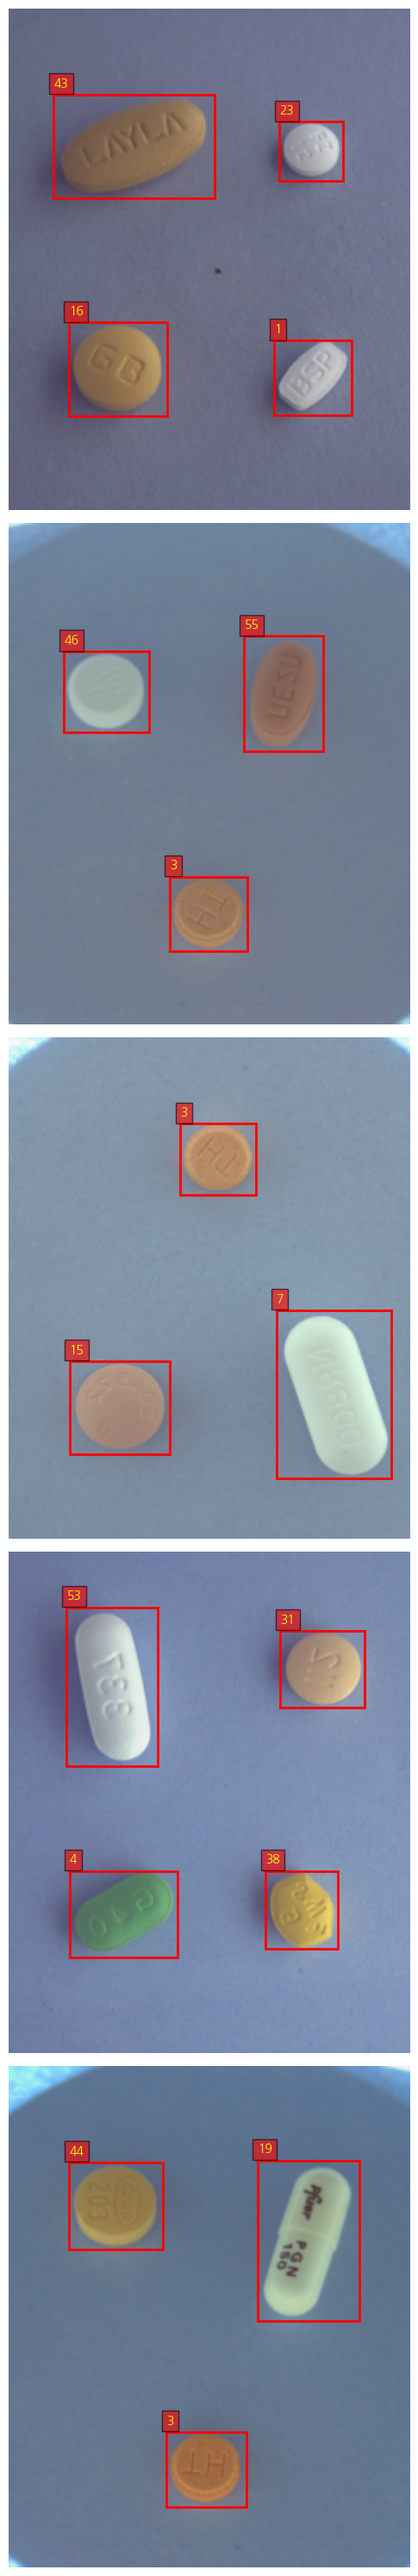

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

def show_samples(dataset, num_samples=5):

    indices = random.sample(range(len(dataset)), num_samples)

    fig, axes = plt.subplots(num_samples, 1, figsize=(10, 6*num_samples))

    if num_samples == 1:
        axes = [axes]

    for ax, idx in zip(axes, indices):

        image, target = dataset[idx]

        # Tensor -> numpy
        img = image.permute(1,2,0).cpu().numpy()

        # Normalize 해제
        mean = [0.485,0.456,0.406]
        std = [0.229,0.224,0.225]

        img = img * std + mean
        img = img.clip(0,1)

        ax.imshow(img)

        boxes = target["boxes"]
        labels = target["labels"]

        for box, label in zip(boxes, labels):

            x1,y1,x2,y2 = box.tolist()

            rect = patches.Rectangle(
                (x1,y1),
                x2-x1,
                y2-y1,
                linewidth=2,
                edgecolor='red',
                facecolor='none'
            )

            ax.add_patch(rect)

            ax.text(
                x1,
                y1-5,
                str(label.item()),
                color="yellow",
                fontsize=10,
                bbox=dict(facecolor="red", alpha=0.6)
            )

        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_samples(full_train_dataset)

지금부터 모델입니다

In [ ]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

def get_model(num_classes):
    # COCO 데이터셋으로 사전학습된 가장 성능 좋은 모델 로드
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn_v2(weights="DEFAULT")

    # 모델의 머리(Classifier 헤더)를 우리 알약 개수에 맞게 교체
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    # num_classes는 (배경 1개 + 알약 종류 수) 로 설정해야 합니다.
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model

In [ ]:
import torch.optim as optim

# 1. 모델 초기화
NUM_CLASSES = len(full_train_dataset.class_map) + 1
model = get_model(num_classes=NUM_CLASSES)
model.to(device)

params = [p for p in model.parameters() if p.requires_grad]

# 2. 🎯 SGD 대신 초반 학습 속도가 미친듯이 빠른 AdamW 사용
optimizer = optim.AdamW(
    params,
    lr=0.0005,          # 너무 크지도, 작지도 않은 황금 학습률로 고정!
    weight_decay=0.0005
)

# 3. 🎯 스케줄러 비활성화 (20에폭의 짧은 학습에서는 고정 LR이 훨씬 좋습니다)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',      # mAP를 모니터링할 거라면 'max' (높을수록 좋음)
    factor=0.5,      # 0.5배로 줄임
    patience=3,      # 3에폭 동안 성능 개선 없으면 낮춤
)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:01<00:00, 123MB/s]


In [ ]:
from tqdm import tqdm

def train_one_epoch(model, loader, optimizer, device):

    model.train()

    epoch_loss = 0

    pbar = tqdm(loader)

    for images, targets in pbar:

        images = [img.to(device) for img in images]

        targets = [
            {k:v.to(device) for k,v in t.items()}
            for t in targets
        ]

        loss_dict = model(images, targets)

        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()

        losses.backward()

        optimizer.step()

        epoch_loss += losses.item()

        pbar.set_description(
            f"loss : {losses.item():.4f}"
        )

    return epoch_loss / len(loader)

In [ ]:
!pip install torchmetrics
from torchmetrics.detection.mean_ap import MeanAveragePrecision

# ==========================================
# 1. mAP 평가 함수 (Validation)
# ==========================================
@torch.no_grad()
def evaluate_map(model, loader, device):
    # ⚠️ 파이토치 모델은 eval() 상태여야 'Loss'가 아닌 '예측 박스 좌표'를 반환합니다.
    model.eval()

    # mAP 계산기 객체 생성
    metric = MeanAveragePrecision(iou_type="bbox")

    pbar = tqdm(loader, desc="[Valid mAP]")
    for images, targets in pbar:
        images = [img.to(device) for img in images]

        # 모델 예측 (예측된 박스, 라벨, 신뢰도 스코어 반환)
        predictions = model(images)

        # 정답지(Targets) 준비
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # metric 업데이트
        metric.update(predictions, targets)

    # 최종 mAP 계산 결과 반환
    return metric.compute()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 43.3 MB/s eta 0:00:00


In [ ]:
@torch.no_grad()

def test_one_epoch(model, loader, device):

    model.eval()

    total_boxes = 0

    for images, targets in loader:

        images = [img.to(device) for img in images]

        outputs = model(images)

        total_boxes += sum(
            len(o["boxes"])
            for o in outputs
        )

    return total_boxes

In [ ]:
import json

EPOCHS = 80
best_map = 0.0 # mAP는 높을수록 좋으므로 0으로 초기화

print("\n🔥 모델 학습 및 Best mAP 가중치 탐색을 시작합니다! 🔥")

for epoch in range(EPOCHS):
    # 1. 학습 (Train)
    train_loss = train_one_epoch(model, train_loader, optimizer, device)

    # 2. 검증 (Validation) - mAP 계산
    map_results = evaluate_map(model, val_loader, device)

    # (추가) 현재 에폭의 mAP 50-95 점수를 변수에 저장
    current_map = map_results['map'].item()

    # 3. 스케줄러 업데이트
    if scheduler is not None:
        scheduler.step(current_map)

    # 현재 학습률(Learning Rate) 가져오기
    current_lr = optimizer.param_groups[0]['lr']

    # 4. JSON 형태의 딕셔너리 생성
    epoch_summary = {
        "map50": map_results['map_50'].item(),       # IoU 0.5 기준 mAP
        "map75": map_results['map_75'].item(),       # IoU 0.75 기준 mAP
        "map50_95": map_results['map'].item(),       # 종합 mAP (가장 중요)
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "lr": current_lr
    }

    # 5. Best 모델 저장 로직 (출력 로직보다 먼저 두어 바로 알림이 뜨게 함)
    if epoch_summary["map50_95"] > best_map:
        print(f"  🌟 mAP가 {best_map:.4f}에서 {epoch_summary['map50_95']:.4f}로 개선되었습니다! (Best Model 저장)")
        best_map = epoch_summary["map50_95"]

        torch.save(
            model.state_dict(),
            "best_fasterrcnn_map.pth"
        )

    # 6. 🎯 출력 조절: 4에폭마다 상세 JSON 출력, 그 외에는 한 줄 요약
    if (epoch + 1) % 4 == 0:
        print(f"\n[Epoch {epoch+1} Detailed Results]")
        print(json.dumps(epoch_summary, indent=4))
    else:
        # 4의 배수가 아닐 때는 진행 상황을 짧게 한 줄로 출력
        print(f"[Epoch {epoch+1:02d}/{EPOCHS}] Train Loss: {train_loss:.4f} | mAP50-95: {epoch_summary['map50_95']:.4f}")


🔥 모델 학습 및 Best mAP 가중치 탐색을 시작합니다! 🔥


[Valid mAP]: 100%|██████████| 6/6 [00:08<00:00,  1.46s/it]


  🌟 mAP가 0.0000에서 0.1671로 개선되었습니다! (Best Model 저장)
[Epoch 01/80] Train Loss: 0.9169 | mAP50-95: 0.1671


[Valid mAP]: 100%|██████████| 6/6 [00:08<00:00,  1.41s/it]


  🌟 mAP가 0.1671에서 0.2405로 개선되었습니다! (Best Model 저장)
[Epoch 02/80] Train Loss: 0.9575 | mAP50-95: 0.2405


...

[Epoch 78/80] Train Loss: 0.4341 | mAP50-95: 0.9518


[Valid mAP]: 100%|██████████| 6/6 [00:08<00:00,  1.45s/it]


[Epoch 79/80] Train Loss: 0.4154 | mAP50-95: 0.9507


[Valid mAP]: 100%|██████████| 6/6 [00:08<00:00,  1.50s/it]



[Epoch 80 Detailed Results]
{
    "map50": 0.9843415021896362,
    "map75": 0.9843415021896362,
    "map50_95": 0.9522733092308044,
    "epoch": 80,
    "train_loss": 0.4355724845081568,
    "lr": 7.8125e-06
}


🌟 Best 모델 로드 완료! 테스트 셋 예측을 시각화합니다.


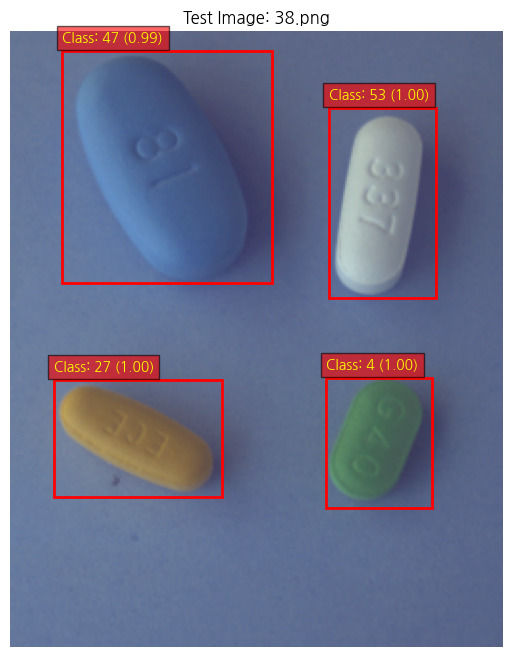

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random
import torch

# ==========================================
# 1. 시각화 함수 (작성하신 코드 유지)
# ==========================================
def show_prediction(model, dataset, device, score_threshold=0.5):
    model.eval()
    idx = random.randint(0, len(dataset)-1)
    image, img_name = dataset[idx]

    with torch.no_grad():
        output = model([image.to(device)])[0]

    # 정규화 해제 (이미지를 원래 색으로 복원)
    mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
    std = torch.tensor([0.229,0.224,0.225]).view(3,1,1)
    img = (image.cpu()*std+mean).clamp(0,1)

    fig, ax = plt.subplots(figsize=(8,8))
    ax.imshow(img.permute(1,2,0))

    for box, score, label in zip(output["boxes"], output["scores"], output["labels"]):
        if score < score_threshold:
            continue

        x1, y1, x2, y2 = box.cpu().numpy()

        rect = patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2, edgecolor="red", facecolor="none"
        )
        ax.add_patch(rect)

        ax.text(
            x1, y1-5,
            f"Class: {label.item()} ({score:.2f})",
            color="yellow", fontsize=10,
            bbox=dict(facecolor="red", alpha=0.6)
        )

    plt.title(f"Test Image: {img_name}")
    plt.axis("off")
    plt.show()


# ==========================================
# 2. 🚀 Best 모델 로드 및 실행
# ==========================================
# 학습 시 사용했던 NUM_CLASSES와 동일해야 합니다.
# (만약 train_dataset이 메모리에 있다면 len(train_dataset.class_map) + 1 을 쓰시면 됩니다)
NUM_CLASSES = len(full_train_dataset.class_map) + 1

# 빈 깡통 모델 생성
best_model = get_model(num_classes=NUM_CLASSES)

# 🎯 앞선 학습 루프에서 저장한 Best 가중치 파일 이름 입력!
# (만약 이름을 다르게 저장하셨다면 그 이름으로 바꿔주세요)
WEIGHTS_PATH = "best_fasterrcnn_map.pth"

# 가중치 덮어씌우기
best_model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=device))
best_model.to(device)
best_model.eval()

print("🌟 Best 모델 로드 완료! 테스트 셋 예측을 시각화합니다.")

# 3. 함수 실행 (원하는 만큼 셀을 반복 실행해서 여러 이미지를 확인해보세요)
show_prediction(best_model, test_dataset, device, score_threshold=0.5)

In [ ]:
import os
import pandas as pd
import torch
import numpy as np
from PIL import Image
from tqdm import tqdm

def generate_submission_csv(model, test_loader, device, reverse_class_map, score_threshold=0.5, save_path="submission.csv"):
    model.eval()

    results = []
    annotation_id = 1

    with torch.no_grad():
        for images, img_names in tqdm(test_loader, desc="[Testing & Saving]"):
            images = [img.to(device) for img in images]

            outputs = model(images)

            for i, output in enumerate(outputs):
                # 1. 파일명에서 확장자(.png)를 떼고 순수 이름만 image_id로 사용
                image_id = img_names[i].split('.')[0]

                # 2. 원본 이미지 크기 읽어오기 및 스케일(Scale) 비율 계산
                orig_img_path = os.path.join(TEST_IMG_DIR, img_names[i])
                with Image.open(orig_img_path) as orig_img:
                    orig_w, orig_h = orig_img.size # 원본 해상도

                # 모델이 쳐다본 텐서 이미지의 해상도 (C, H, W)
                _, model_h, model_w = images[i].shape

                # 원본 크기로 복원하기 위한 가중치 비율
                scale_x = orig_w / model_w
                scale_y = orig_h / model_h

                boxes = output['boxes'].cpu().numpy()
                scores = output['scores'].cpu().numpy()
                labels = output['labels'].cpu().numpy()

                # ====================================================
                # 🌟 핵심 1: Score 0.5 이상인 박스만 1차 필터링
                # ====================================================
                keep_idx = scores >= score_threshold
                boxes = boxes[keep_idx]
                scores = scores[keep_idx]
                labels = labels[keep_idx]

                # ====================================================
                # 🌟 핵심 2: 남은 박스가 4개를 초과하면 상위 4개만 남기기
                # ====================================================
                if len(scores) > 4:
                    # 점수(scores)를 내림차순 정렬했을 때의 상위 4개 인덱스 추출
                    top_k_indices = scores.argsort()[::-1][:4]
                    boxes = boxes[top_k_indices]
                    scores = scores[top_k_indices]
                    labels = labels[top_k_indices]

                # 필터링이 끝난 최종 박스들만 순회하며 CSV에 기록
                for box, score, label in zip(boxes, scores, labels):
                    x1, y1, x2, y2 = box

                    # 3. 원본 스케일로 좌표 복원
                    orig_x1 = x1 * scale_x
                    orig_y1 = y1 * scale_y
                    orig_x2 = x2 * scale_x
                    orig_y2 = y2 * scale_y

                    w = orig_x2 - orig_x1
                    h = orig_y2 - orig_y1

                    # 4. 모델이 예측한 라벨을 원래 category_id로 복원
                    original_category_id = reverse_class_map.get(label, label)

                    # 5. 좌표는 반올림 후 정수로 변환, 점수는 소수점 둘째 자리까지
                    results.append({
                        "annotation_id": annotation_id,
                        "image_id": image_id,
                        "category_id": original_category_id,
                        "bbox_x": int(round(float(orig_x1))), # 🚨 수정 완료: x1 -> orig_x1
                        "bbox_y": int(round(float(orig_y1))), # 🚨 수정 완료: y1 -> orig_y1
                        "bbox_w": int(round(float(w))),
                        "bbox_h": int(round(float(h))),
                        "score": round(float(score), 2)
                    })
                    annotation_id += 1

    df = pd.DataFrame(results)
    df.to_csv(save_path, index=False, encoding='utf-8')
    print(f"\n✅ 테스트 결과가 '{save_path}'에 성공적으로 저장되었습니다. (총 {len(df)}개 박스 탐지)")

    return df

# ==========================================
# 2. 🌟 Best 가중치 덮어씌우기 (Load)
# ==========================================
NUM_CLASSES = len(full_train_dataset.class_map) + 1
best_model = get_model(num_classes=NUM_CLASSES)
best_model.to(device)

WEIGHTS_PATH = "best_fasterrcnn_map.pth"

# 저장된 가중치를 불러와서 모델에 적용합니다.
best_model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=device))
best_model.eval() # 추론 모드로 확실하게 고정
print(f"✅ 최고 성능의 '{WEIGHTS_PATH}' 가중치 로드 완료! 테스트 추론을 시작합니다.\n")

# ==========================================
# 3. 최종 정답지(CSV) 추출 실행
# ==========================================
# 라벨 복원용 맵퍼 준비
reverse_class_map = {v: k for k, v in full_train_dataset.class_map.items()}
CSV_FILE_NAME = "final_submission.csv"

# 🎯 실행단에서 score_threshold를 직접 컨트롤하도록 수정 완료!
df_submission = generate_submission_csv(
    model=best_model,
    test_loader=test_loader,
    device=device,
    reverse_class_map=reverse_class_map,
    score_threshold=0.5,  # <-- 여기서 커트라인을 자유롭게 조절하세요!
    save_path=CSV_FILE_NAME
)

# 추출된 정답지 상위 10개 미리보기
display(df_submission.head(10))

✅ 최고 성능의 'best_fasterrcnn_map.pth' 가중치 로드 완료! 테스트 추론을 시작합니다.



[Testing & Saving]: 100%|██████████| 106/106 [02:42<00:00,  1.53s/it]


✅ 테스트 결과가 'final_submission.csv'에 성공적으로 저장되었습니다. (총 3219개 박스 탐지)


,annotation_id,image_id,category_id,bbox_x,bbox_y,bbox_w,bbox_h,score
0,1,1,1900,156,254,204,122,0.98
1,2,1,16551,563,61,399,427,0.97
2,3,1,27926,587,659,272,502,0.82
3,4,1,13900,178,754,174,274,0.72
4,5,10,1900,644,844,188,188,1.00
5,6,10,16548,102,806,239,240,1.00
6,7,10,29451,96,238,422,222,0.96
7,8,10,21771,638,286,194,187,0.56
8,9,100,1900,133,244,195,161,1.00
9,10,100,16548,581,131,238,227,0.99


In [ ]:
from google.colab import files
files.download(CSV_FILE_NAME)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import json

WEIGHTS_PATH = "best_fasterrcnn_map.pth"
model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=device))
print("✅ Best 모델 가중치 로드 완료! 가장 똑똑했던 상태에서 이어서 학습을 시작합니다.")

EPOCHS = 20
best_map = 0.0 # mAP는 높을수록 좋으므로 0으로 초기화

print("\n🔥 모델 학습 및 Best mAP 가중치 탐색을 시작합니다! 🔥")

for epoch in range(EPOCHS):
    # 1. 학습 (Train)
    train_loss = train_one_epoch(model, train_loader, optimizer, device)

    # 2. 검증 (Validation) - mAP 계산
    map_results = evaluate_map(model, val_loader, device)

    # 3. 스케줄러 업데이트
    if scheduler is not None:
        scheduler.step()

    # 현재 학습률(Learning Rate) 가져오기
    current_lr = optimizer.param_groups[0]['lr']

    # 4. JSON 형태의 딕셔너리 생성
    epoch_summary = {
        "map50": map_results['map_50'].item(),       # IoU 0.5 기준 mAP
        "map75": map_results['map_75'].item(),       # IoU 0.75 기준 mAP
        "map50_95": map_results['map'].item(),       # 종합 mAP (가장 중요)
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "lr": current_lr
    }

    # 5. Best 모델 저장 로직 (출력 로직보다 먼저 두어 바로 알림이 뜨게 함)
    if epoch_summary["map50_95"] > best_map:
        print(f"  🌟 mAP가 {best_map:.4f}에서 {epoch_summary['map50_95']:.4f}로 개선되었습니다! (Best Model 저장)")
        best_map = epoch_summary["map50_95"]

        torch.save(
            model.state_dict(),
            "best_fasterrcnn_map.pth"
        )

    # 6. 🎯 출력 조절: 4에폭마다 상세 JSON 출력, 그 외에는 한 줄 요약
    if (epoch + 1) % 4 == 0:
        print(f"\n[Epoch {epoch+1} Detailed Results]")
        print(json.dumps(epoch_summary, indent=4))
    else:
        # 4의 배수가 아닐 때는 진행 상황을 짧게 한 줄로 출력
        print(f"[Epoch {epoch+1:02d}/{EPOCHS}] Train Loss: {train_loss:.4f} | mAP50-95: {epoch_summary['map50_95']:.4f}")